# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cfc115"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[8.347 8.347 8.347 ... 8.375 8.375 8.375] [8.347 8.347 8.347 ... 8.375 8.375 8.375] [8.347 8.347 8.347 ... 8.375 8.375 8.375] [8.347 8.347 8.347 ... 8.375 8.375 8.375] [8.347 8.347 8.347 ... 8.375 8.375 8.375] [8.347 8.347 8.347 ... 8.375 8.375 8.375]] [[8.349 8.349 8.349 ... 8.368 8.368 8.368] [8.349 8.349 8.349 ... 8.368 8.368 8.368] [8.349 8.349 8.349 ... 8.368 8.368 8.368] [8.349 8.349 8.349 ... 8.368 8.368 8.368] [8.349 8.349 8.349 ... 8.368 8.368 8.368] [8.349 8.349 8.349 ... 8.368 8.368 8.368]] [[8.331 8.331 8.331 ... 8.359 8.359 8.359] [8.331 8.331 8.331 ... 8.359 8.359 8.359] [8.331 8.331 8.331 ... 8.359 8.359 8.359] [8.331 8.331 8.331 ... 8.359 8.359 8.359] [8.331 8.331 8.331 ... 8.359 8.359 8.359] [8.331 8.331 8.331 ... 8.359 8.359 8.359]] ... [[8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.971 8.925333333333333 8.916] [8.893 8.893 8.893 ... 8.951 8.9335 8.916] [8.893 8.893 8.893 ... 8.942833333333333 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916]] [[8.899 8.899 8.899 ... 8.951333333333334 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.951333333333332 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.974 8.943666666666665 8.936] [8.899 8.899 8.899 ... 8.955666666666668 8.945833333333333 8.936] [8.899 8.899 8.899 ... 8.9535 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.951333333333332 8.943666666666667 8.936]] [[8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.959083333333334 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.961500000000001 8.95375 8.946] [8.906 8.906 8.906 ... 8.959083333333334 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[8.379 8.379 8.379 ... 8.397 8.397 8.397] [8.379 8.379 8.379 ... 8.397 8.397 8.397] [8.379 8.379 8.379 ... 8.397 8.397 8.397] [8.379 8.379 8.379 ... 8.397 8.397 8.397] [8.379 8.379 8.379 ... 8.397 8.397 8.397] [8.379 8.379 8.379 ... 8.397 8.397 8.397]] [[8.363 8.363 8.363 ... 8.405 8.405 8.405] [8.363 8.363 8.363 ... 8.405 8.405 8.405] [8.363 8.363 8.363 ... 8.405 8.405 8.405] [8.363 8.363 8.363 ... 8.405 8.405 8.405] [8.363 8.363 8.363 ... 8.405 8.405 8.405] [8.363 8.363 8.363 ... 8.405 8.405 8.405]] [[8.343 8.343 8.343 ... 8.385 8.385 8.385] [8.343 8.343 8.343 ... 8.385 8.385 8.385] [8.343 8.343 8.343 ... 8.385 8.385 8.385] [8.343 8.343 8.343 ... 8.385 8.385 8.385] [8.343 8.343 8.343 ... 8.385 8.385 8.385] [8.343 8.343 8.343 ... 8.385 8.385 8.385]] ... [[8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.971 8.925333333333333 8.916] [8.893 8.893 8.893 ... 8.951 8.9335 8.916] [8.893 8.893 8.893 ... 8.942833333333333 8.925333333333334 8.916] [8.893 8.893 8.893 ... 8.934666666666667 8.925333333333334 8.916]] [[8.899 8.899 8.899 ... 8.951333333333334 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.951333333333332 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.974 8.943666666666665 8.936] [8.899 8.899 8.899 ... 8.955666666666668 8.945833333333333 8.936] [8.899 8.899 8.899 ... 8.9535 8.943666666666667 8.936] [8.899 8.899 8.899 ... 8.951333333333332 8.943666666666667 8.936]] [[8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.959083333333334 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.961500000000001 8.95375 8.946] [8.906 8.906 8.906 ... 8.959083333333334 8.951333333333332 8.946] [8.906 8.906 8.906 ... 8.956666666666665 8.951333333333332 8.946]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cfc115' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[8.379      8.363      8.343      ... 8.34       8.346
    8.343     ]
   [8.33       8.389      8.364      ... 8.363      8.395
    8.389     ]
   [8.387      8.432      8.324      ... 8.38       8.369
    8.346     ]
   ...
   [8.675      8.688      8.689      ... 8.725      8.731
    8.737     ]
   [8.747      8.731      8.736      ... 8.824      8.833
    8.831     ]
   [8.838      8.845      8.847      ... 8.893      8.899
    8.906     ]]

  [[8.379      8.363      8.343      ... 8.34       8.346
    8.343     ]
   [8.33       8.389      8.364      ... 8.363      8.395
    8.389     ]
   [8.387      8.432      8.324      ... 8.38       8.369
    8.346     ]
...
   [8.753      8.76833333 8.76533333 ... 8.81566667 8.818
    8.831     ]
   [8.84       8.86233333 8.85133333 ... 8.90633333 8.91933333
    8.915     ]
   [8.94       8.94266667 8.94566667 ... 8.92533333 8.94366667
    8.95133333]]

  [[8.397      8.405      8.385      ... 8.396      8.414
    8.408     ]
   [8.408      8.377      8.373      ... 8.4        8.406
    8.402     ]
   [8.39       8.386      8.384      ... 8.43       8.432
    8.425     ]
   ...
   [8.754      8.775      8.767      ... 8.816      8.812
    8.824     ]
   [8.839      8.859      8.843      ... 8.891      8.917
    8.906     ]
   [8.939      8.941      8.943      ... 8.916      8.936
    8.946     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.934666666666667 8.951333333333334 8.956666666666665] [8.397 8.405 8.385 ... 8.925333333333334 8.943666666666667 8.951333333333332] [8.397 8.405 8.385 ... 8.916 8.936 8.946]] [[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.934666666666667 8.951333333333332 8.956666666666665] [8.397 8.405 8.385 ... 8.925333333333334 8.943666666666667 8.951333333333332] [8.397 8.405 8.385 ... 8.916 8.936 8.946]] [[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.971 8.974 8.959083333333334] [8.397 8.405 8.385 ... 8.925333333333333 8.943666666666665 8.951333333333332] [8.397 8.405 8.385 ... 8.916 8.936 8.946]] [[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.951 8.955666666666668 8.961500000000001] [8.397 8.405 8.385 ... 8.9335 8.945833333333333 8.95375] [8.397 8.405 8.385 ... 8.916 8.936 8.946]] [[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.942833333333333 8.9535 8.959083333333334] [8.397 8.405 8.385 ... 8.925333333333334 8.943666666666667 8.951333333333332] [8.397 8.405 8.385 ... 8.916 8.936 8.946]] [[8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] [8.379 8.363 8.343 ... 8.893 8.899 8.906] ... [8.397 8.405 8.385 ... 8.934666666666667 8.951333333333332 8.956666666666665] [8.397 8.405 8.385 ... 8.925333333333334 8.943666666666667 8.951333333333332] [8.397 8.405 8.385 ... 8.916 8.936 8.946]]]
Units,ppt


### Longitudinal-mean

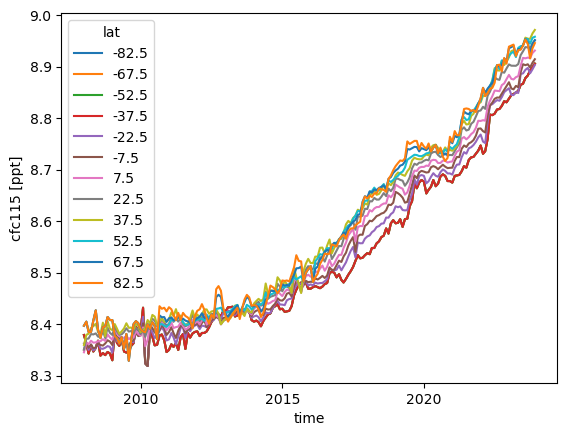

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

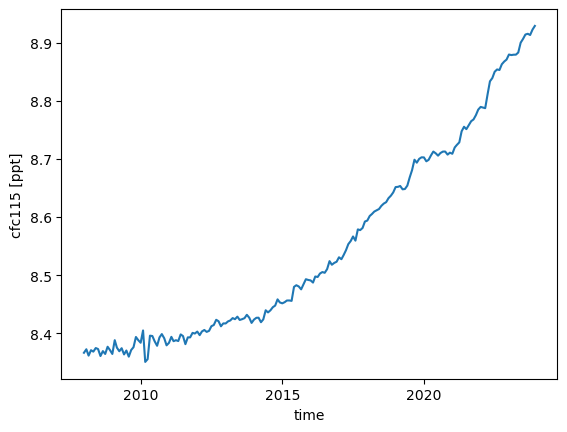

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

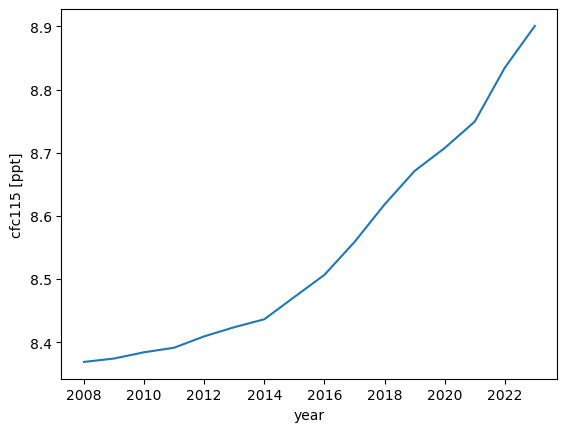

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3382 ... 1.896e-07
    principal-components  (year, eof) float64 2kB [] -0.0635 ... 1.283e-19

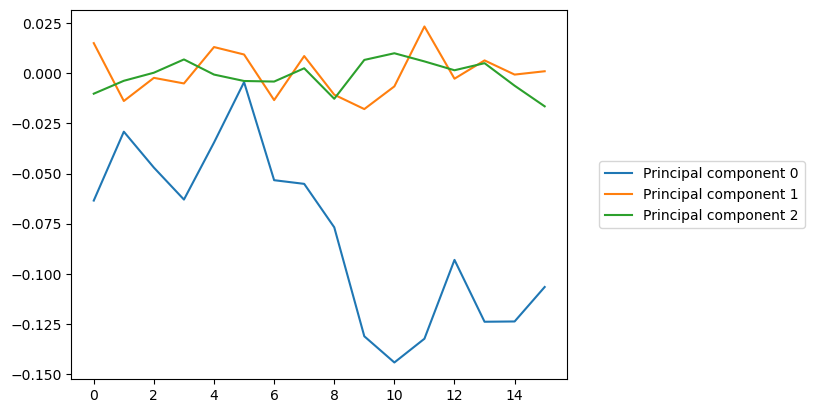

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

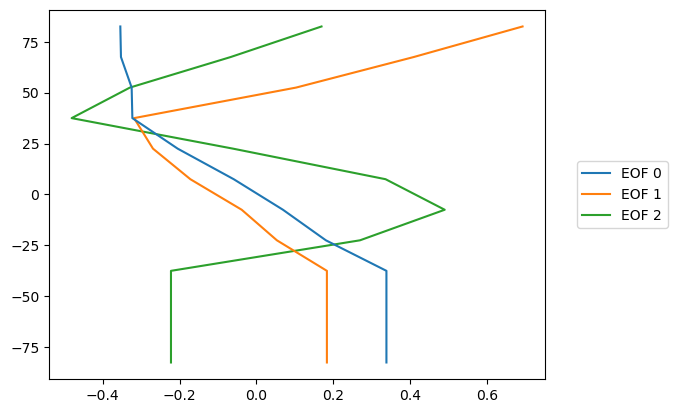

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

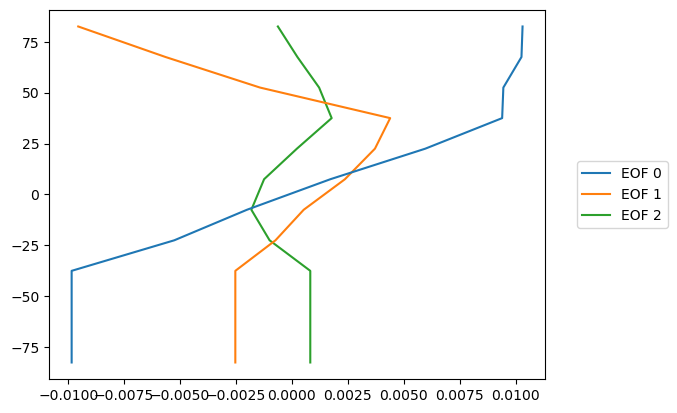

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.33822698156661013] [0.3382269815666103] [0.3382269815666102] [0.3382269815666102] [0.180603997357996] [0.06894521449862684] [-0.0591596660168218] [-0.20492451873976072] [-0.32290629598405174] [-0.3247576945496529] [-0.3525888636680916] [-0.3542455672204874]]
Units,ppt
Magnitude,[[-0.06349789624529026] [-0.029112528828314648] [-0.047036382417352765] [-0.06299760305562181] [-0.03453266698419798] [-0.0043683751433241415] [-0.05332508603366529] [-0.05515610378393435] [-0.07685172656309364] [-0.13125312991243637] [-0.1443281011980519] [-0.1324710373083921] [-0.09311368196958532] [-0.12399570171522765] [-0.1238513043326978] [-0.10664414769886454]]
Units,dimensionless


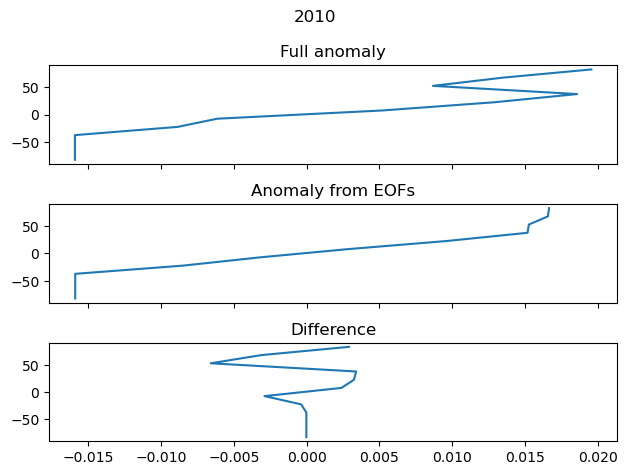

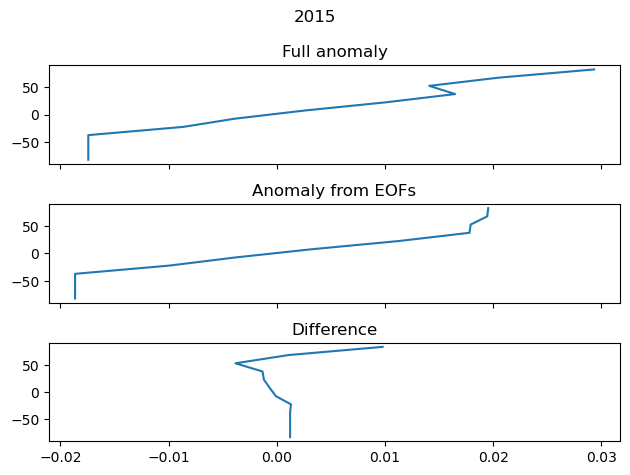

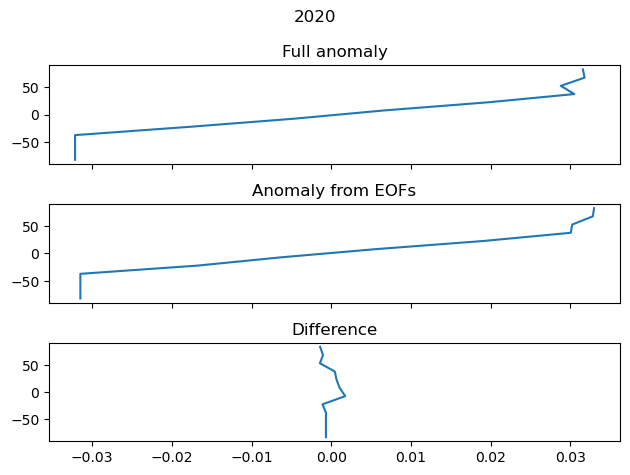

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 15358.77it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19690.61it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19700.72it/s]

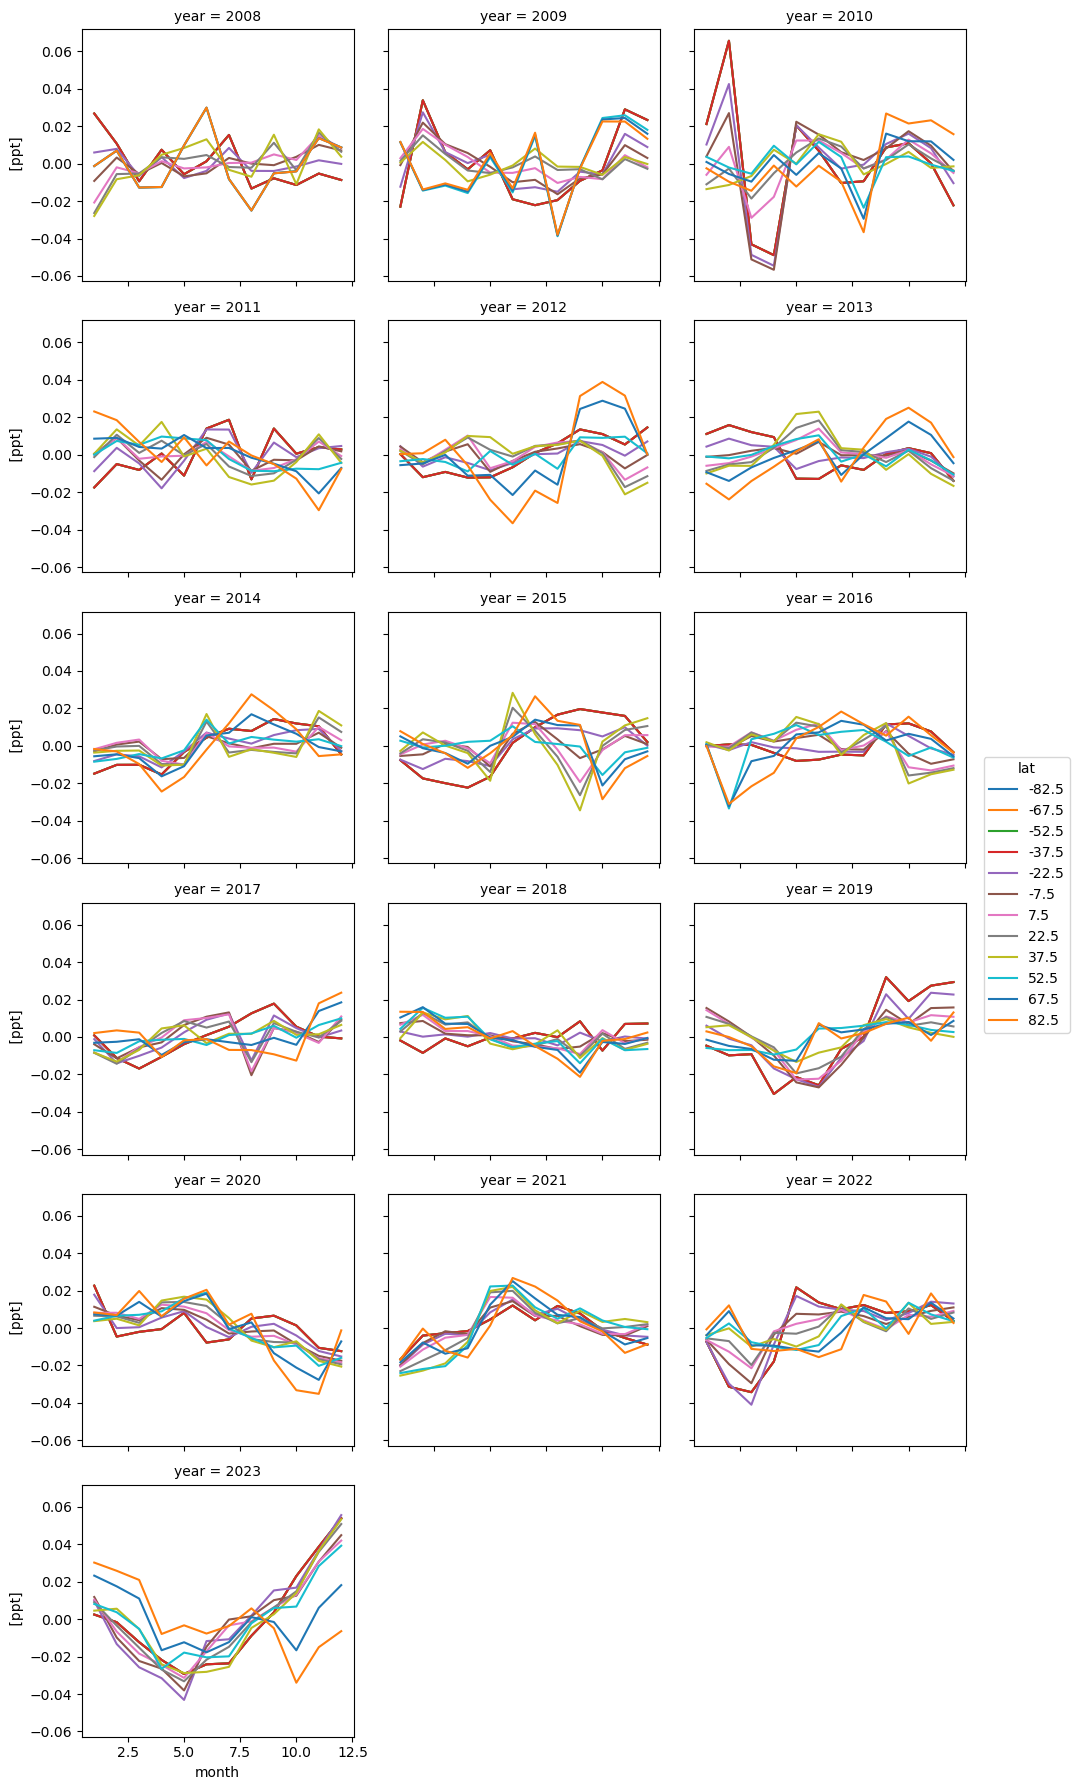

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

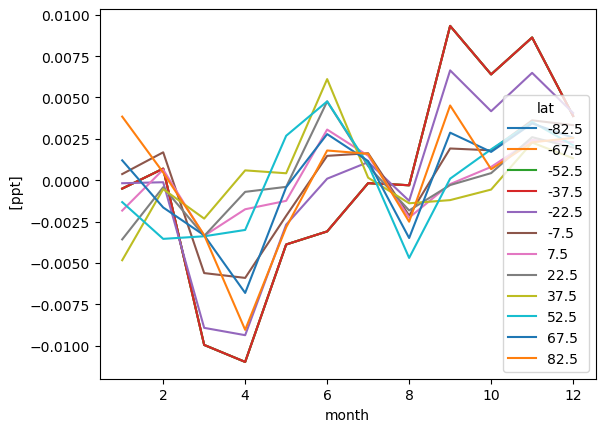

In [22]:
seasonality.plot.line(hue="lat")

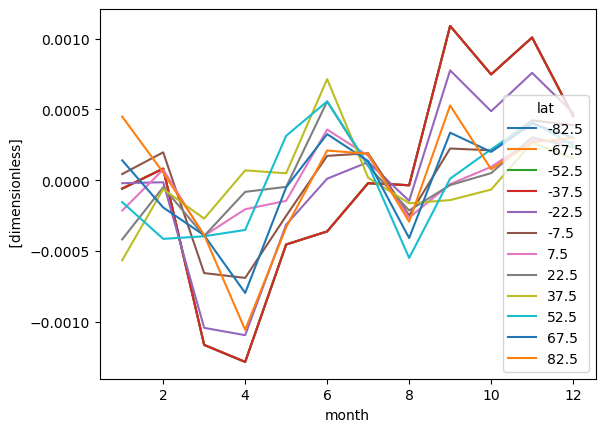

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[8.368922791485492 8.374270200937426 8.384179261364947 8.391389148882547 8.409360565240005 8.423849423899002 8.43642825297646 8.471680339350092 8.506772040225414 8.55865280127997 8.618073922605396 8.671124935650893 8.70732853498662 8.749199163580775 8.834449109499143 8.900610707792358]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.33822698156661013] [0.3382269815666103] [0.3382269815666102] [0.3382269815666102] [0.180603997357996] [0.06894521449862684] [-0.0591596660168218] [-0.20492451873976072] [-0.32290629598405174] [-0.3247576945496529] [-0.3525888636680916] [-0.3542455672204874]]
Units,ppt
Magnitude,[[-0.06349789624529026] [-0.029112528828314648] [-0.047036382417352765] [-0.06299760305562181] [-0.03453266698419798] [-0.0043683751433241415] [-0.05332508603366529] [-0.05515610378393435] [-0.07685172656309364] [-0.13125312991243637] [-0.1443281011980519] [-0.1324710373083921] [-0.09311368196958532] [-0.12399570171522765] [-0.1238513043326978] [-0.10664414769886454]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-5.965341750367143e-05 8.160180868511645e-05 -0.0011651050409436352 -0.0012852386362880543 -0.00045482064746022496 -0.00036233882873010453 -2.0946247241613473e-05 -3.587287616802454e-05 0.0010909304680088475 0.0007480699462046778 0.0010091465139720453 0.0004542320065795022] [-5.965341750367143e-05 8.160180868511645e-05 -0.0011651050409436352 -0.0012852386362880543 -0.00045482064746022496 -0.00036233882873010453 -2.0946247241613473e-05 -3.587287616802454e-05 0.0010909304680088475 0.0007480699462046778 0.0010091465139720453 0.0004542320065795022] [-5.965341750367143e-05 8.160180868511645e-05 -0.0011651050409436352 -0.0012852386362880543 -0.00045482064746022496 -0.00036233882873010453 -2.0946247241613473e-05 -3.587287616802454e-05 0.0010909304680088475 0.0007480699462046778 0.0010091465139720453 0.0004542320065795022] [-5.965341750367143e-05 8.160180868511645e-05 -0.0011651050409436352 -0.0012852386362880543 -0.00045482064746022496 -0.00036233882873010453 -2.0946247241613473e-05 -3.587287616802454e-05 0.0010909304680088475 0.0007480699462046778 0.0010091465139720453 0.0004542320065795022] [-2.1515082845632054e-05 -1.4551893842307404e-05 -0.0010443089755619115 -0.0010961199637602164 -0.00031441902562257397 1.0584210801576531e-05 0.00012777187048707003 -0.0001459225249259098 0.000776578244877496 0.0004877274705770023 0.0007589489006921742 0.00047523383565721707] [4.323115419967295e-05 0.0001970708017201374 -0.0006569726597441586 -0.0006910589898188112 -0.00025212466851759534 0.00017197813810786896 0.00019064800322018393 -0.0002506893285391177 0.00022409749064806344 0.00021129605067634144 0.00042322923285578897 0.000389299503086927] [-0.0002150287301614938 7.528838692793933e-05 -0.00039322482221011625 -0.00020558681719983488 -0.00014609436920531442 0.00035799819951519137 0.000172874477425079 -0.0002649740053989376 -2.765299999772355e-05 9.381083109349227e-05 0.0002839828851075901 0.00026861097470903605] [-0.00041874665049825764 -4.965803052331727e-05 -0.00039430987412368405 -8.255061228245793e-05 -4.711960317708797e-05 0.000557109868364781 9.925941666608357e-05 -0.000214008401472331 -3.446474567342743e-05 4.990001500006708e-05 0.00030413354332162103 0.00023046120459429767] [-0.0005662146680957828 -6.314115155715684e-05 -0.0002716727968112236 6.938977052726684e-05 4.88883371102153e-05 0.0007149244384428025 1.7497857812721773e-05 -0.0001633688932221974 -0.00014089811650547663 -6.63014202537625e-05 0.0002657961376995257 0.0001551072214774809] [-0.00015509878736154792 -0.0004149929859836046 -0.0003966710824415376 -0.0003518581281937718 0.0003140596887725959 0.0005571788356619474 0.00010999395158229139 -0.0005498686332323165 1.0691126731958057e-05 0.00021808614121571914 0.00041165273966709925 0.00024683275596733143] [0.0001402599072061707 -0.00019298645517742909 -0.00038962224710854413 -0.0007974125116527212 -5.004767537424189e-05 0.0003259318313996137 0.00013558772689230416 -0.00040907436571986053 0.0003359718552793375 0.00020003894407285804 0.00040133323831300873 0.0003000220044846103] [0.00044959867873203786 5.410912229199905e-05 -0.00038811710683181395 -0.0010584397703497792 -0.0003332464123846676 0.00020996858080553682 0.0001865421796417277 -0.00029368052514527036 0.0005283320973086294 7.789613865363048e-05 0.0002677102162241699 0.0002993245251530377]]
Units,dimensionless
